# Tracer Gradients

This notebook is to calculate tracer gradients in 3 spatial dimensions. I think this will help with interpretation of the results metrics.

## Housekeeping

In [272]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate
from flox.xarray import xarray_reduce
from xgcm.autogenerate import generate_grid_ds
from xgcm import Grid
from tqdm.notebook import tqdm
from scipy.ndimage import uniform_filter1d

In [273]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff
import density_funcs as df

In [274]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [275]:
ds_r_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_r_grid_copilot.nc')

In [276]:
ds_r_grid = ds_r_grid.rename_vars({'CT_sort':'CT_m_bin', 'SA_sort':'SA_m_bin', 'SPICE_sort':'SPICE_m_bin',
                                   'PRESSURE':'PRESSURE_m_bin'})

In [277]:
basin = xr.open_dataset('/swot/SUM05/amf2288/basin.nc')
basin_on_grid = basin.sel(Z=0).interp(lat=ds_r_grid.LAT, lon=ds_r_grid.LON, method='nearest')
ds_r_grid['basin'] = (('LAT','LON'), basin_on_grid.basin.data)

## Construct Land Mask

In [278]:
FILL = -999
vars_to_fill = ["CT_m_bin", "SA_m_bin", "SPICE_m_bin"]
for v in vars_to_fill:
    ds_r_grid[v] = ds_r_grid[v].fillna(FILL)

In [279]:
ds_r_grid["data_mask"] = xr.where(ds_r_grid["CT_m_bin"] == FILL, 0, 1) 

## Compute gradients

In [302]:
grid = Grid(ds_r_grid, coords={
        'X': {'center': 'LON', 'left': 'LON_left'},
        'Y': {'center': 'LAT', 'left': 'LAT_left'},
        'Z': {'center': 'DENSITY'}}, 
        periodic=['X'], boundary={'Y':'fill'})

In [324]:
distance_1deg = 111000  # meters

def get_grad(ds, grid, var):
    """
    Compute horizontal gradients d(var)/dx and d(var)/dy on cell centers
    using xgcm, with proper face metrics and masking.
    Uses:
      dx = 111 km * cos(lat)
      dy = 111 km
    Ensures:
      - No division across land/NaN
      - No single-cell spikes
      - Final gradients have the SAME NaN mask as the tracer
    """

    # ---------------------------------------------------------
    # 1. Center mask (1 = ocean, 0 = land/NaN)
    # ---------------------------------------------------------
    mask_center = ds["data_mask"]

    # Face masks: valid only if BOTH neighbors are valid
    mask_x = grid.min(mask_center, "X")
    mask_y = grid.min(mask_center, "Y")

    # ---------------------------------------------------------
    # 2. Metrics on faces (in meters)
    # ---------------------------------------------------------
    # X-faces: Δlon in degrees, lat broadcast to faces
    dlon_face = grid.diff(ds["LON"], "X")  # degrees
    lat_face = ds["LAT"].broadcast_like(dlon_face)

    dx_face = distance_1deg * np.cos(np.deg2rad(lat_face)) * dlon_face

    # Y-faces: Δlat in degrees
    dlat_face = grid.diff(ds["LAT"], "Y")  # degrees
    dy_face = distance_1deg * dlat_face

    # ---------------------------------------------------------
    # 3. Raw differences on faces
    # ---------------------------------------------------------
    dvar_dx_num = grid.diff(ds[var], "X")
    dvar_dy_num = grid.diff(ds[var], "Y")

    # ---------------------------------------------------------
    # 4. Mask BEFORE division (critical!)
    # ---------------------------------------------------------
    dvar_dx_num = dvar_dx_num.where(mask_x == 1)
    dvar_dy_num = dvar_dy_num.where(mask_y == 1)

    # ---------------------------------------------------------
    # 5. Safe division (avoid 0 or NaN metrics)
    # ---------------------------------------------------------
    dx_face_safe = dx_face.where(np.isfinite(dx_face) & (dx_face != 0))
    dy_face_safe = dy_face.where(np.isfinite(dy_face) & (dy_face != 0))

    dvar_dx_face = dvar_dx_num / dx_face_safe
    dvar_dy_face = dvar_dy_num / dy_face_safe

    # ---------------------------------------------------------
    # 6. Interpolate back to centers
    # ---------------------------------------------------------
    dvar_dx = grid.interp(dvar_dx_face, "X", to="center")
    dvar_dy = grid.interp(dvar_dy_face, "Y", to="center")

    # ---------------------------------------------------------
    # 7. Enforce SAME mask as tracer (prevents NaN expansion)
    # ---------------------------------------------------------
    dvar_dx = dvar_dx.where(mask_center == 1)
    dvar_dy = dvar_dy.where(mask_center == 1)

    return dvar_dx, dvar_dy

In [325]:
ds_r_grid['dCT_m_dx'], ds_r_grid['dCT_m_dy'] = get_grad(ds_r_grid, grid, 'CT_m_bin')
ds_r_grid['dSA_m_dx'], ds_r_grid['dSA_m_dy'] = get_grad(ds_r_grid, grid, 'SA_m_bin')
ds_r_grid['dSPICE_m_dx'], ds_r_grid['dSPICE_m_dy'] = get_grad(ds_r_grid, grid, 'SPICE_m_bin')

In [326]:
def interp_to_pmean(var_profile, pres_profile, pmean_grid):
    """
    Interpolate a variable from its density-coordinate to a mean pressure grid.
    Each profile uses its own pressure-density relationship.
    
    Args:
        var_profile: 1D array of variable values along rho_grid for one profile
        pres_profile: 1D array of pressure values along rho_grid for one profile (unsorted)
        pmean_grid: Target pressure grid for output
    
    Returns:
        1D array of var interpolated to pmean_grid
    """
    try:
        # Sort the pressure profile for this specific profile
        valid = ~np.isnan(pres_profile)
        
        if not np.any(valid):
            return np.full_like(pmean_grid, np.nan)
        
        # Get valid region boundaries
        i0 = np.argmax(valid)
        i1 = len(pres_profile) - np.argmax(valid[::-1])
        
        # Sort the core region of pressure
        pres_core = pres_profile[i0:i1]
        core_sort_idx = np.argsort(pres_core)
        
        # Apply sorting to pressure only (not variable)
        pres_sorted = pres_core[core_sort_idx]
        var_core = var_profile[i0:i1]
        
        # Remove NaNs from variable (keeping original density order)
        valid_var = ~np.isnan(var_core)
        pres_nonan = pres_sorted[valid_var]
        var_nonan = var_core[valid_var]
        
        if len(pres_nonan) < 3:
            return np.full_like(pmean_grid, np.nan)
        
        # Interpolate to pmean_grid
        fvar = interpolate.PchipInterpolator(pres_nonan, var_nonan, extrapolate=False)
        return fvar(pmean_grid)
    
    except (ValueError, IndexError):
        return np.full_like(pmean_grid, np.nan)

In [327]:
from tqdm.auto import tqdm

def get_ds_pmean(ds_rho, pres_var, pmean_grid, variables, dim1='PROFILE', dim2='DENSITY'):
    """
    Convert dataset from density coordinates to mean pressure coordinates.
    Each profile uses its own pressure-density relationship.
    
    Args:
        ds_rho: xarray Dataset on density coordinates
        pres_var: name of pressure variable in ds_rho (e.g., 'PRESSURE_sort0')
        pmean_grid: 1D numpy array of target pressure levels
        variables: list of variable names to interpolate
        dim1: profile dimension name (default 'PROF')
        dim2: density dimension name (default 'rho_grid')
    
    Returns:
        xarray Dataset on pmean_grid coordinates
    """
    xrs = []
    pmean_size = pmean_grid.size
    
    # Process each variable with progress bar
    for var in tqdm(variables, desc="Processing variables"):
        var_interp = xr.apply_ufunc(
            interp_to_pmean, 
            ds_rho[var], 
            ds_rho[pres_var],
            input_core_dims=[[dim2], [dim2]],
            output_core_dims=[['pmean_grid']],
            dask_gufunc_kwargs={'output_sizes': {'pmean_grid': pmean_size}},
            vectorize=True,
            dask='parallelized',
            kwargs={'pmean_grid': pmean_grid},
            output_dtypes=[ds_rho[var].dtype]
        )
        
        var_interp = xr.DataArray(
            data=var_interp.data,
            dims=[dim1, 'pmean_grid'],
            coords={'pmean_grid': pmean_grid, dim1: ds_rho[dim1]},
            name=var
        )
        xrs.append(var_interp)
    
    # Merge all variables
    ds_pmean = xr.merge(xrs)
    
    # Copy coordinate variables
    ds_pmean = ds_pmean.assign_coords(LAT=(dim1, ds_rho.LAT.data))
    ds_pmean = ds_pmean.assign_coords(LON=(dim1, ds_rho.LON.data))
    if 'TIME' in ds_rho.coords:
        ds_pmean = ds_pmean.assign_coords(TIME=(dim1, ds_rho.TIME.data))
    
    return ds_pmean

In [328]:
LON_left = ds_r_grid.LON_left
LAT_left = ds_r_grid.LAT_left
ds_core = ds_r_grid.drop_vars(["LON_left", "LAT_left"])

In [329]:
ds_r_stacked = ds_core.stack(PROFILE=("LON", "LAT"))
ds_r_stacked = ds_r_stacked.reset_index("PROFILE")

In [330]:
ds_pbar_stacked = get_ds_pmean(ds_r_stacked, 'PRESSURE_mean', np.arange(0,2001,2), ['CT_m_bin','SA_m_bin','SPICE_m_bin','DENSITY',
                                                                     'dCT_m_dx', 'dCT_m_dy',
                                                                     'dSA_m_dx', 'dSA_m_dy',
                                                                     'dSPICE_m_dx', 'dSPICE_m_dy'])

Processing variables:   0%|          | 0/10 [00:00<?, ?it/s]

/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/amf2288/miniconda3/envs/Argo_old_xgcm/lib/python3.11/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_

In [331]:
SENTINEL = -9.223372036854776e+18
THRESH = SENTINEL / 2

def clean_sentinel(ds, limit=1e10):
    """Mask any absurd values (sentinels, overflows, corrupted floats)."""
    return ds.where(np.abs(ds) < limit)

ds_pbar_stacked = clean_sentinel(ds_pbar_stacked)

In [332]:
ds_pbar_grid = ds_pbar_stacked.set_index(PROFILE=("LON", "LAT")).unstack("PROFILE").rename({'pmean_grid':'PRESSURE_mean'})
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left=LON_left, LAT_left=LAT_left)

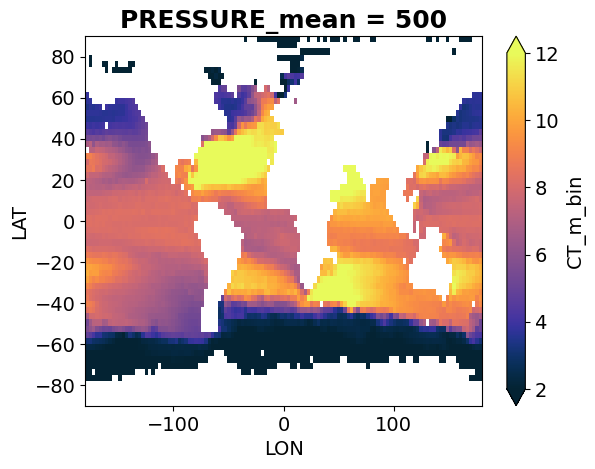

In [333]:
ds_pbar_grid.sel(PRESSURE_mean=500).CT_m_bin.plot(x='LON', y='LAT', cmap=cmo.thermal, vmin=2, vmax=12)

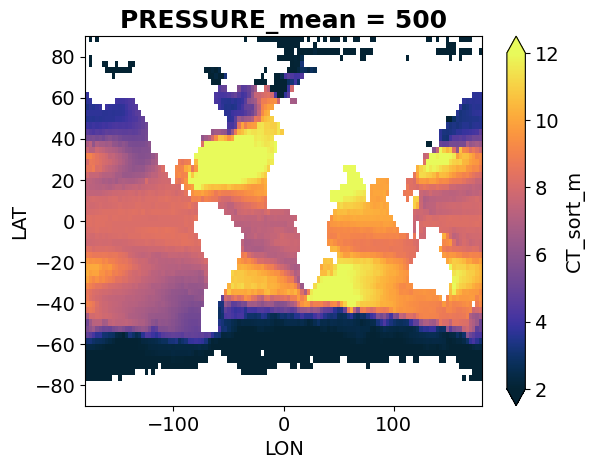

In [334]:
ds_pbar.sel(PRESSURE_mean=500).CT_sort_m.plot(x='LON', y='LAT', cmap=cmo.thermal, vmin=2, vmax=12)

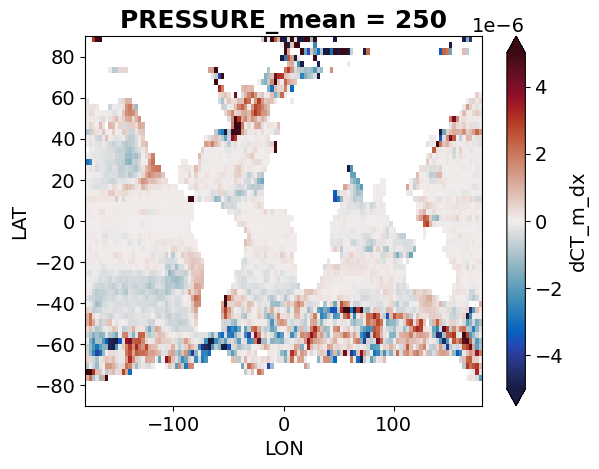

In [335]:
ds_pbar_grid.sel(PRESSURE_mean=250).dCT_m_dx.plot(x='LON',y='LAT', cmap=cmo.balance, vmin=-5e-6, vmax=5e-6)

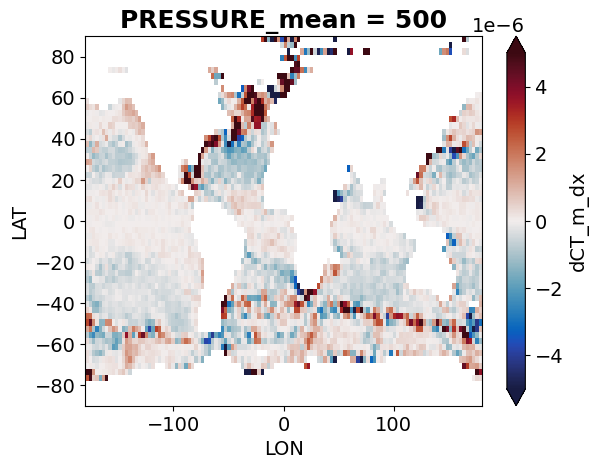

In [336]:
ds_pbar.sel(PRESSURE_mean=500).dCT_m_dx.plot(x='LON',y='LAT', cmap=cmo.balance, vmin=-5e-6, vmax=5e-6)

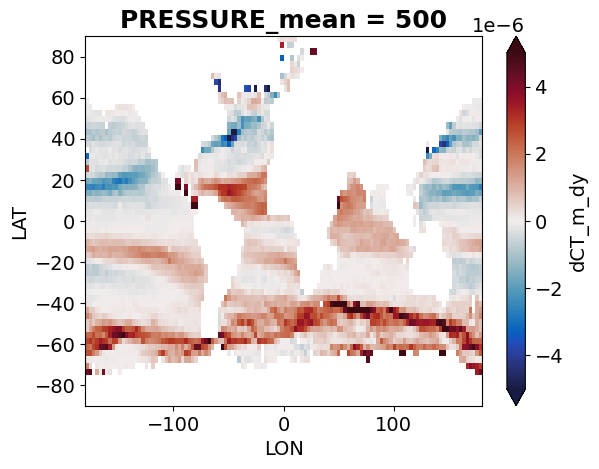

In [337]:
ds_pbar_grid.sel(PRESSURE_mean=500).dCT_m_dy.plot(x='LON',y='LAT', cmap=cmo.balance, vmin=-5e-6, vmax=5e-6)

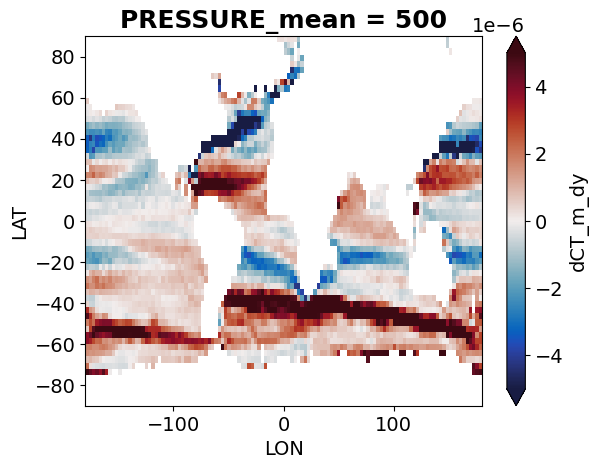

In [338]:
ds_pbar.sel(PRESSURE_mean=500).dCT_m_dy.plot(x='LON',y='LAT', cmap=cmo.balance, vmin=-5e-6, vmax=5e-6)

In [339]:
basin = xr.open_dataset('/swot/SUM05/amf2288/basin.nc')
basin_on_grid = basin.sel(Z=0).interp(lat=ds_pbar_grid.LAT, lon=ds_pbar_grid.LON, method='nearest')
ds_pbar_grid['basin'] = (('LAT','LON'), basin_on_grid.basin.data)

In [340]:
def get_vgrad(ds_gridded, grid, var):
    # --- vertical gradient (pressure coordinate) ---
    p = ds_gridded.PRESSURE_mean
    dp = p.diff('PRESSURE_mean')
    dp = dp.broadcast_like(ds_gridded[var])

    dC_dp = -ds_gridded[var].diff('PRESSURE_mean') / dp

    # restore original coordinate length without duplicates
    dC_dp = dC_dp.reindex(PRESSURE_mean=ds_gridded.PRESSURE_mean)

    return dC_dp

In [341]:
ds_temp = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')

In [342]:
ds_pbar_grid['dCT_m_dp'] = get_vgrad(ds_temp, grid, 'CT_sort_m')
ds_pbar_grid['dSA_m_dp'] = get_vgrad(ds_temp, grid, 'SA_sort_m')
ds_pbar_grid['dSPICE_m_dp'] = get_vgrad(ds_temp, grid, 'SPICE_sort_m')

In [343]:

ds_pbar_grid

<xarray.Dataset> Size: 750MB
Dimensions:        (LON: 120, LAT: 60, PRESSURE_mean: 1001, LON_left: 120,
                    LAT_left: 60)
Coordinates:
  * LON            (LON) float64 960B -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT            (LAT) float64 480B -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * PRESSURE_mean  (PRESSURE_mean) int64 8kB 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON_left       (LON_left) float64 960B -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left       (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/14)
    CT_m_bin       (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    SA_m_bin       (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    SPICE_m_bin    (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    DENSITY        (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    dCT_m_dx       (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    dCT_m_dy       (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    ...             ...
    dSPICE_m_dx    (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    dSPICE_m_dy    (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    basin          (LAT, LON) float64 58kB nan nan nan nan ... nan nan nan nan
    dCT_m_dp       (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    dSA_m_dp       (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan
    dSPICE_m_dp    (PRESSURE_mean, LON, LAT) float64 58MB nan nan ... nan nan

In [323]:
ds_pbar_grid.to_netcdf('/swot/SUM05/amf2288/ds_pbar_grad_bin.nc')